# 03 · Satisfacción: qué explica una mala reseña

**Proyecto:** Olist · **Datos:** `data/df_EDA.csv` y, para la parte B, `data/raw/olist_order_reviews_dataset.csv` (Kaggle)

El EDA mostró que el retraso hunde la calificación. Este notebook lo cuantifica y responde:

- **A. Modelo:** ¿qué factores del pedido explican una reseña de 1–2 estrellas, y cuánto pesa cada uno?
- **B. Texto:** ¿de qué se quejan los clientes cuando escriben un comentario?

**Decisiones de diseño**

| Decisión | Por qué |
|---|---|
| Una fila por **pedido** | La reseña es del pedido. Entrenar sobre el archivo plano repite pedidos y mezcla filas del mismo pedido entre entrenamiento y test |
| Objetivo **binario**: insatisfecho = 1–2★ | Es lo accionable (un detractor). Un modelo de 5 clases con 59% de 5★ termina prediciendo casi todo como 5★ |
| **Validación temporal** | Se entrena con pedidos hasta feb-2018 y se evalúa con los de mar–ago 2018, como se usaría en la realidad |
| Sin variables de calendario sueltas (`month_year`, día del mes) | No explican la experiencia del cliente y hacen que el modelo memorice períodos |
| Métricas **ROC AUC** y **precisión promedio** | Con 13% de clase positiva, la exactitud (*accuracy*) engaña: predecir "todos satisfechos" ya da 87% |

In [1]:
# Solo en Google Colab: monta Drive y se ubica en la carpeta de notebooks del proyecto.
# Si la carpeta compartida tiene otro nombre en tu Drive, cambiá CARPETA.
import os, sys
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    CARPETA = "/content/drive/MyDrive/Proyecto Olist"
    os.chdir(f"{CARPETA}/notebooks")
    sys.path.insert(0, os.getcwd())

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from olist_utils import (
    RAW, cargar_eda, nivel_pedido, nivel_item, nivel_pago,
    estilo, tabla, fmt_pct, barras_h, AZUL, NARANJA, VERDE, GRIS, MAL, TINTA_2,
)

estilo()
df = cargar_eda()
pedidos, items, pagos = nivel_pedido(df), nivel_item(df), nivel_pago(df)

## A.1 Dataset de modelado: una fila por pedido

Se agregan a cada pedido variables de **entrega**, **contenido**, **pago** y **geografía**, todas conocidas al momento de recibir el pedido.

In [3]:
por_pedido_items = items.groupby("order_id").agg(
    n_items=("order_item_id", "size"),
    n_vendedores=("seller_id", "nunique"),
    n_productos=("product_id", "nunique"),
    precio_productos=("price", "sum"),
    flete=("freight_value", "sum"),
    region_vendedor=("seller_region", "first"),
)
# macro-categoría del ítem más caro del pedido
principal = items.sort_values("price", ascending=False).drop_duplicates("order_id").set_index("order_id")["macro_category"]
cuotas = pagos.groupby("order_id")["payment_installments"].max()

m = (pedidos.set_index("order_id")
     .join(por_pedido_items).join(principal).join(cuotas)
     .dropna(subset=["review_score"]).reset_index())

m["insatisfecho"] = (m["review_score"] <= 2).astype(int)
m["dias_retraso"] = m["delivery_delay"].clip(lower=0)             # días después de la fecha prometida
m["dias_margen"] = (-m["delivery_delay"]).clip(lower=0)            # días antes de la fecha prometida
m["plazo_prometido"] = (m["order_estimated_delivery_date"] - m["order_purchase_timestamp"]).dt.days
# ~1% de los pedidos tiene fechas invertidas (despacho antes de la aprobación): se recortan a 0
m["dias_preparacion"] = m["prep_time"].clip(lower=0)
m["dias_transporte"] = (m["order_delivered_customer_date"] - m["order_delivered_carrier_date"]).dt.days.clip(lower=0)
m["flete_pct"] = m["flete"] / m["precio_productos"]
m["misma_region"] = (m["customer_region"] == m["region_vendedor"]).astype(int)
m["varios_vendedores"] = (m["n_vendedores"] > 1).astype(int)

NUMERICAS = ["dias_retraso", "dias_margen", "plazo_prometido", "dias_preparacion", "dias_transporte",
             "n_items", "n_vendedores", "precio_ticket", "flete_pct", "payment_installments", "misma_region"]
CATEGORICAS = ["customer_region", "macro_category", "most_frequent_payment_type"]

print(f"{len(m):,} pedidos con reseña · {m['insatisfecho'].mean():.1%} insatisfechos (1–2★)")
m[NUMERICAS].describe().T[["mean", "50%", "min", "max"]]

95,479 pedidos con reseña · 12.8% insatisfechos (1–2★)


,mean,50%,min,max
dias_retraso,0.70,0.00,0.00,188.00
dias_margen,12.61,12.00,0.00,147.00
plazo_prometido,23.36,23.00,2.00,155.00
dias_preparacion,2.31,1.00,0.00,125.00
dias_transporte,8.84,7.00,0.00,205.00
n_items,1.14,1.00,1.00,21.00
n_vendedores,1.01,1.00,1.00,5.00
precio_ticket,159.76,105.28,9.59,"13,664.08"
flete_pct,0.31,0.23,0.00,21.45
payment_installments,2.93,2.00,0.00,24.00


## A.2 Antes del modelo: tasas observadas

El modelo tiene que confirmar lo que ya se ve en los datos. Tres cortes simples:

In [4]:
def tasa(col, etiquetas=None):
    t = m.groupby(col)["insatisfecho"].agg(["mean", "size"])
    if etiquetas:
        t = t.rename(index=etiquetas)
    return t

cortes = pd.concat({
    "Entrega": tasa("late_delivery", {False: "a tiempo", True: "con retraso"}),
    "Vendedores en el pedido": tasa("varios_vendedores", {0: "uno", 1: "varios"}),
    "Ítems en el pedido": tasa(m["n_items"].clip(upper=3).map({1: "1", 2: "2", 3: "3 o más"})),
})
cortes.columns = ["% insatisfechos", "pedidos"]
tabla(cortes, {"% insatisfechos": "{:.1%}", "pedidos": "{:,.0f}"})

% insatisfechos pedidos
Entrega                 a tiempo               9.3%  89,109
                        con retraso           62.4%   6,370
Vendedores en el pedido uno                   12.4%  94,218
                        varios                47.3%   1,261
Ítems en el pedido      1                     11.3%  85,989
                        2                     25.4%   7,287
                        3 o más               31.2%   2,203

In [5]:
a_tiempo = m[~m["late_delivery"]]
print(f"Aun entregando a tiempo, el {a_tiempo['insatisfecho'].mean():.1%} de los pedidos recibe 1–2★.")
print(f"Entre ellos, con varios vendedores: {a_tiempo.loc[a_tiempo['varios_vendedores'] == 1, 'insatisfecho'].mean():.1%} "
      f"vs. un vendedor: {a_tiempo.loc[a_tiempo['varios_vendedores'] == 0, 'insatisfecho'].mean():.1%}")
print("Hipótesis: un pedido con varios vendedores llega en varios paquetes y el cliente califica cuando recibe el primero, incompleto.")

Aun entregando a tiempo, el 9.3% de los pedidos recibe 1–2★.
Entre ellos, con varios vendedores: 47.0% vs. un vendedor: 8.7%
Hipótesis: un pedido con varios vendedores llega en varios paquetes y el cliente califica cuando recibe el primero, incompleto.


## A.3 Entrenamiento con validación temporal

In [6]:
corte = pd.Timestamp("2018-03-01")
train = m[m["order_purchase_timestamp"] < corte]
test = m[m["order_purchase_timestamp"] >= corte]
X_train, y_train = train[NUMERICAS + CATEGORICAS], train["insatisfecho"]
X_test, y_test = test[NUMERICAS + CATEGORICAS], test["insatisfecho"]
print(f"Entrenamiento: {len(train):,} pedidos (hasta feb-2018) · {y_train.mean():.1%} insatisfechos")
print(f"Test:          {len(test):,} pedidos (mar–ago 2018) · {y_test.mean():.1%} insatisfechos")

preproceso = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
])
modelos = {
    "Línea base (azar estratificado)": make_pipeline(preproceso, DummyClassifier(strategy="stratified", random_state=42)),
    "Regresión logística": make_pipeline(preproceso, LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Gradient boosting": make_pipeline(preproceso, HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=31, class_weight="balanced", random_state=42)),
}

resultados, probas = {}, {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    p = modelo.predict_proba(X_test)[:, 1]
    probas[nombre] = p
    # ¿qué % de las malas reseñas se concentra en el 10% de pedidos con más riesgo?
    top10 = p >= np.quantile(p, 0.9)
    resultados[nombre] = {
        "ROC AUC": roc_auc_score(y_test, p),
        "Precisión promedio": average_precision_score(y_test, p),
        "Malas reseñas en el top 10% de riesgo": y_test[top10].sum() / y_test.sum(),
        "Precisión en el top 10%": y_test[top10].mean(),
    }

resultados = pd.DataFrame(resultados).T
tabla(resultados, {"ROC AUC": "{:.3f}", "Precisión promedio": "{:.3f}",
                   "Malas reseñas en el top 10% de riesgo": "{:.0%}", "Precisión en el top 10%": "{:.0%}"})

Entrenamiento: 56,862 pedidos (hasta feb-2018) · 13.2% insatisfechos
Test:          38,617 pedidos (mar–ago 2018) · 12.3% insatisfechos


,ROC AUC,Precisión promedio,Malas reseñas en el top 10% de riesgo,Precisión en el top 10%
Línea base (azar estratificado),0.499,0.123,13%,12%
Regresión logística,0.752,0.418,42%,52%
Gradient boosting,0.754,0.461,43%,53%


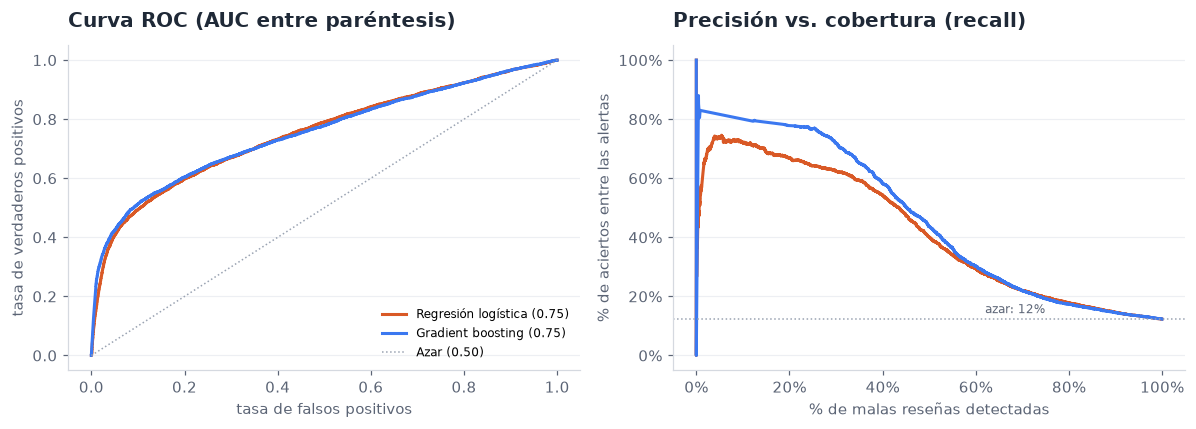

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
curvas = {k: v for k, v in probas.items() if k != "Línea base (azar estratificado)"}
for (nombre, p), color in zip(curvas.items(), [NARANJA, AZUL]):
    fpr, tpr, _ = roc_curve(y_test, p)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{nombre} ({roc_auc_score(y_test, p):.2f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax2.plot(rec, prec, color=color, lw=2, label=nombre)
ax1.plot([0, 1], [0, 1], color=GRIS, ls=":", lw=1, label="Azar (0.50)")
ax1.set_title("Curva ROC (AUC entre paréntesis)")
ax1.set_xlabel("tasa de falsos positivos"); ax1.set_ylabel("tasa de verdaderos positivos")
ax1.legend(loc="lower right", fontsize=8)
ax2.axhline(y_test.mean(), color=GRIS, ls=":", lw=1)
ax2.text(0.62, y_test.mean() + 0.02, f"azar: {y_test.mean():.0%}", color=TINTA_2, fontsize=8)
ax2.set_title("Precisión vs. cobertura (recall)")
ax2.set_xlabel("% de malas reseñas detectadas"); ax2.set_ylabel("% de aciertos entre las alertas")
fmt_pct(ax2); fmt_pct(ax2, eje="x")
fig.tight_layout()
plt.show()

## A.4 ¿Qué variables pesan?

**Importancia por permutación** sobre el conjunto de test: cuánto empeora el AUC del gradient boosting si se desordena al azar cada variable.
Es más confiable que la importancia interna de los árboles, que favorece a las variables con muchos valores distintos.

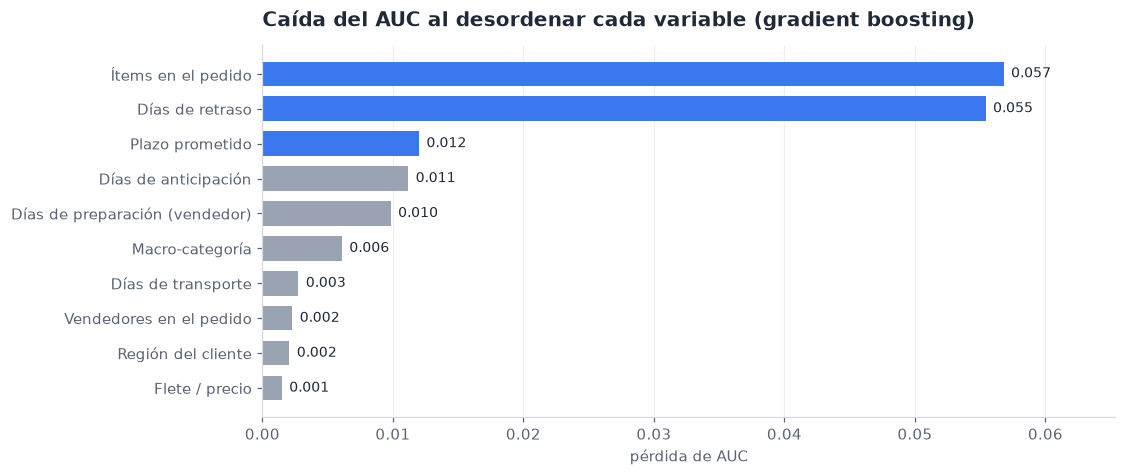

In [8]:
gb = modelos["Gradient boosting"]
imp = permutation_importance(gb, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=42)
importancia = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False)
nombres = {
    "dias_retraso": "Días de retraso", "dias_margen": "Días de anticipación", "plazo_prometido": "Plazo prometido",
    "dias_preparacion": "Días de preparación (vendedor)", "dias_transporte": "Días de transporte",
    "n_items": "Ítems en el pedido", "n_vendedores": "Vendedores en el pedido", "precio_ticket": "Ticket (R$)",
    "flete_pct": "Flete / precio", "payment_installments": "Cuotas", "misma_region": "Vendedor en la región del cliente",
    "customer_region": "Región del cliente", "macro_category": "Macro-categoría", "most_frequent_payment_type": "Medio de pago",
}
barras_h(importancia.rename(nombres).head(10), "Caída del AUC al desordenar cada variable (gradient boosting)",
         fmt="{:.3f}", resaltar=3, xlabel="pérdida de AUC")
plt.show()

La regresión logística permite leer la **dirección** del efecto. Con variables estandarizadas, el coeficiente indica cuánto cambian
las chances (*odds*) de una mala reseña por cada desvío estándar de la variable, manteniendo el resto constante.

In [9]:
lr = modelos["Regresión logística"]
coef = pd.Series(lr[-1].coef_[0], index=lr[0].get_feature_names_out())
coef_num = coef[[f"num__{c}" for c in NUMERICAS]].rename(lambda c: nombres[c.replace("num__", "")])
efecto = pd.DataFrame({"coeficiente": coef_num, "odds × por 1 desvío": np.exp(coef_num)}).sort_values("coeficiente", ascending=False)
tabla(efecto, {"coeficiente": "{:+.2f}", "odds × por 1 desvío": "×{:.2f}"})

,coeficiente,odds × por 1 desvío
Días de retraso,+1.01,×2.74
Plazo prometido,+0.50,×1.65
Ítems en el pedido,+0.34,×1.40
Vendedores en el pedido,+0.18,×1.20
Cuotas,+0.04,×1.04
Días de preparación (vendedor),+0.03,×1.03
Flete / precio,+0.01,×1.01
Vendedor en la región del cliente,+0.01,×1.01
Ticket (R$),+0.01,×1.01
Días de transporte,-0.08,×0.92


## A.5 Impacto de negocio: ¿cuánto se gana entregando a tiempo?

Escenario simple, basado en tasas observadas (no en el modelo): si los pedidos retrasados tuvieran la misma tasa de insatisfacción
que los entregados a tiempo. Es una cota superior, porque asume que el retraso es la causa.

In [10]:
tasa_tiempo = m.loc[~m["late_delivery"], "insatisfecho"].mean()
tasa_actual = m["insatisfecho"].mean()
n_tarde = m["late_delivery"].sum()
tasa_escenario = (m.loc[~m["late_delivery"], "insatisfecho"].sum() + n_tarde * tasa_tiempo) / len(m)
evitables = m.loc[m["late_delivery"], "insatisfecho"].sum() - n_tarde * tasa_tiempo
print(f"Insatisfechos hoy: {tasa_actual:.1%} → sin retrasos: {tasa_escenario:.1%}")
print(f"≈ {evitables:,.0f} reseñas de 1–2★ evitables ({evitables / m['insatisfecho'].sum():.0%} del total), "
      f"sobre {n_tarde:,} pedidos retrasados.")

Insatisfechos hoy: 12.8% → sin retrasos: 9.3%
≈ 3,385 reseñas de 1–2★ evitables (28% del total), sobre 6,370 pedidos retrasados.


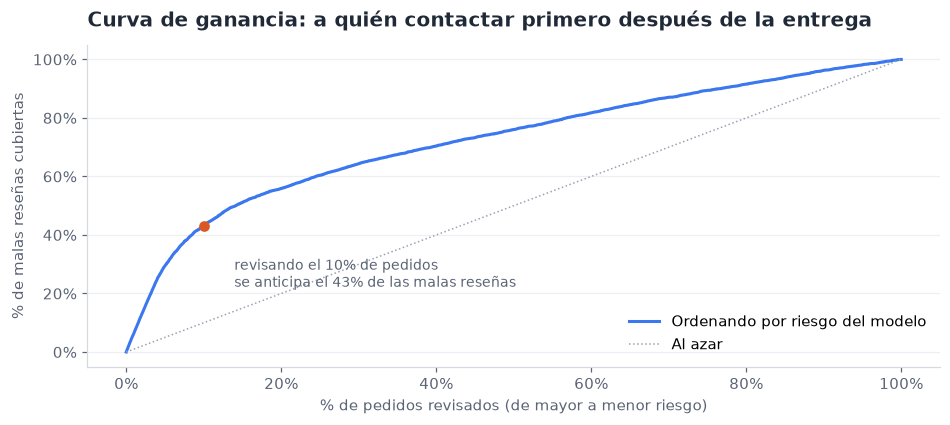

In [11]:
p_gb = probas["Gradient boosting"]
alerta = test.assign(riesgo=p_gb).sort_values("riesgo", ascending=False)
alerta["% acumulado de malas reseñas"] = alerta["insatisfecho"].cumsum() / alerta["insatisfecho"].sum()
alerta["% de pedidos revisados"] = np.arange(1, len(alerta) + 1) / len(alerta)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(alerta["% de pedidos revisados"], alerta["% acumulado de malas reseñas"], color=AZUL, lw=2, label="Ordenando por riesgo del modelo")
ax.plot([0, 1], [0, 1], color=GRIS, ls=":", lw=1, label="Al azar")
x10 = alerta.loc[alerta["% de pedidos revisados"] <= 0.1, "% acumulado de malas reseñas"].iloc[-1]
ax.scatter([0.1], [x10], color=NARANJA, zorder=3)
ax.annotate(f"revisando el 10% de pedidos\nse anticipa el {x10:.0%} de las malas reseñas", (0.1, x10),
            xytext=(20, -40), textcoords="offset points", fontsize=9, color=TINTA_2)
ax.set_title("Curva de ganancia: a quién contactar primero después de la entrega")
ax.set_xlabel("% de pedidos revisados (de mayor a menor riesgo)")
ax.set_ylabel("% de malas reseñas cubiertas")
fmt_pct(ax); fmt_pct(ax, eje="x")
ax.legend(loc="lower right")
plt.show()

## B. Qué dicen los comentarios

Los comentarios escritos no están en `df_EDA.csv`: se leen del archivo original de reseñas de Kaggle.
Se entrena un clasificador **TF-IDF + regresión logística** con las estrellas como etiqueta (1–2★ negativo, 4–5★ positivo)
y se usan sus pesos para ver qué palabras distinguen una queja. Es liviano, se puede explicar y no necesita GPU.

> Si `data/raw/olist_order_reviews_dataset.csv` no está, esta parte se saltea sin error.

In [12]:
ruta_resenas = RAW / "olist_order_reviews_dataset.csv"
HAY_TEXTO = ruta_resenas.exists()
if HAY_TEXTO:
    resenas = pd.read_csv(ruta_resenas, parse_dates=["review_creation_date"])
    resenas = resenas.sort_values("review_creation_date").drop_duplicates("order_id", keep="last")
    textos = resenas.dropna(subset=["review_comment_message"]).query("review_score != 3").copy()
    textos["negativo"] = (textos["review_score"] <= 2).astype(int)
    print(f"{len(resenas):,} reseñas · {len(textos):,} con comentario y 1–2★ o 4–5★ · {textos['negativo'].mean():.0%} negativas")
else:
    print(f"No encontré {ruta_resenas.name}: descargá el dataset de Kaggle en data/raw/ para correr esta parte.")

98,673 reseñas · 37,239 con comentario y 1–2★ o 4–5★ · 29% negativas


In [13]:
if HAY_TEXTO:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics import classification_report
    from sklearn.model_selection import train_test_split

    # sin tildes, igual que el texto después de strip_accents
    STOP = ("a o e de da do das dos em no na nos nas um uma para com por que se ao os as mas mais "
            "foi ser esta isso esse essa meu minha muito bem ja me eu").split()
    tr, te = train_test_split(textos, test_size=0.25, stratify=textos["negativo"], random_state=42)
    texto_modelo = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=5, strip_accents="unicode", lowercase=True, stop_words=STOP),
        LogisticRegression(max_iter=2000, class_weight="balanced"),
    )
    texto_modelo.fit(tr["review_comment_message"], tr["negativo"])
    pred = texto_modelo.predict(te["review_comment_message"])
    print(classification_report(te["negativo"], pred, target_names=["positivo", "negativo"], digits=3))

              precision    recall  f1-score   support

    positivo      0.975     0.925     0.949      6600
    negativo      0.838     0.941     0.887      2710

    accuracy                          0.930      9310
   macro avg      0.906     0.933     0.918      9310
weighted avg      0.935     0.930     0.931      9310



Los comentarios están en portugués. Glosario de los términos que aparecen:
*nao* = no · *nao recebi* = no recibí · *comprei* = compré · *pessimo/a* = pésimo/a · *diferente* = distinto al publicado ·
*quebrado* = roto · *ruim* = malo · *aguardando* = esperando · *faltando* = falta algo ·
*antes* = llegó antes · *parabens* = felicitaciones · *otimo/a* = excelente · *amei* = me encantó · *rapido/a* = rápido/a.

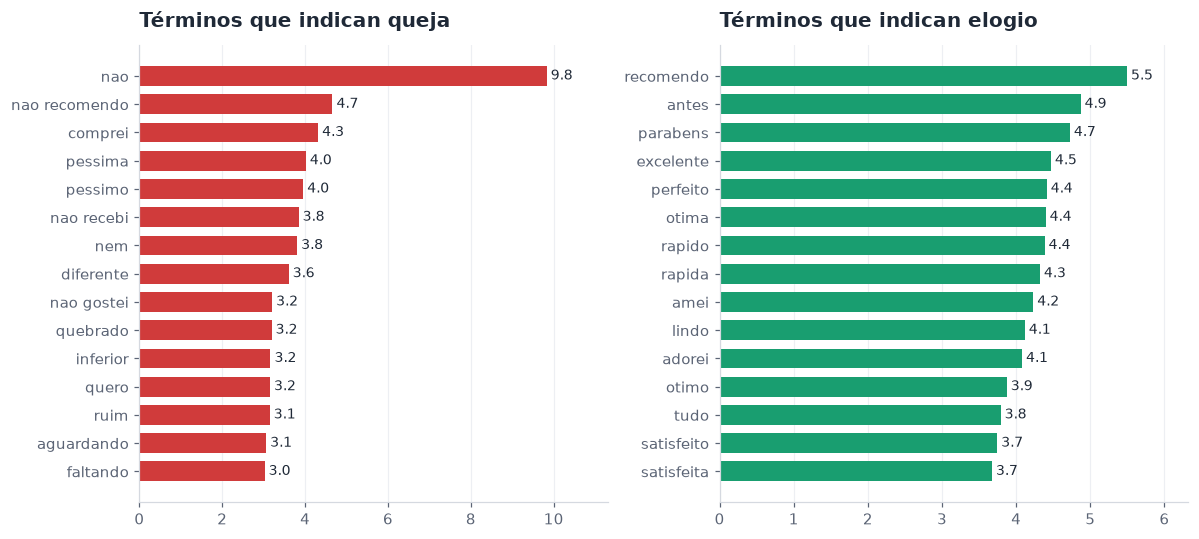

In [14]:
if HAY_TEXTO:
    vocab = texto_modelo[0].get_feature_names_out()
    pesos = pd.Series(texto_modelo[-1].coef_[0], index=vocab)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
    barras_h(pesos.nlargest(15), "Términos que indican queja", ax=ax1, color=MAL, fmt="{:.1f}")
    barras_h(-pesos.nsmallest(15), "Términos que indican elogio", ax=ax2, color=VERDE, fmt="{:.1f}")
    fig.tight_layout()
    plt.show()

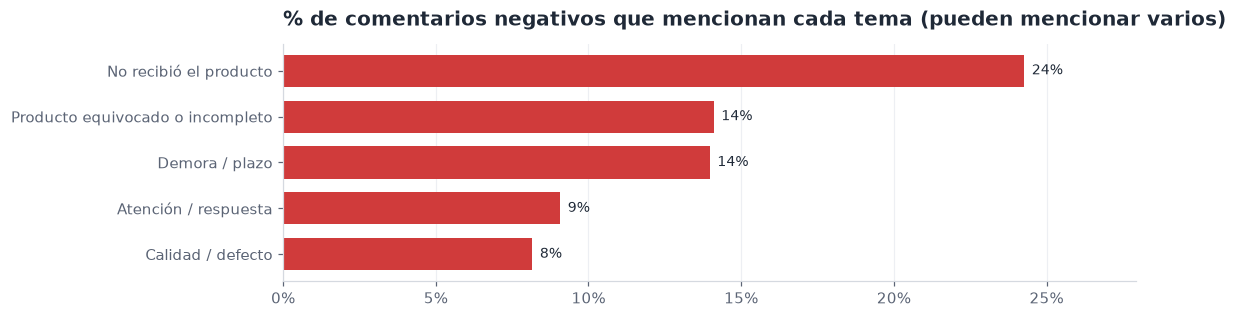

In [15]:
if HAY_TEXTO:
    temas = {
        "No recibió el producto": r"n[aã]o receb|nao cheg|n[aã]o chegou|ainda n[aã]o",
        "Demora / plazo": r"atras|demor|prazo",
        "Producto equivocado o incompleto": r"errad|diferente|faltou|falta|incomplet|apenas um|s[oó] um",
        "Calidad / defecto": r"defeit|quebrad|qualidade|danific",
        "Atención / respuesta": r"atendimento|respost|contato|reclama",
    }
    neg = textos[textos["negativo"] == 1]["review_comment_message"].str.lower()
    menciones = pd.Series({t: neg.str.contains(rx, regex=True).mean() for t, rx in temas.items()}).sort_values(ascending=False)
    barras_h(menciones, "% de comentarios negativos que mencionan cada tema (pueden mencionar varios)", color=MAL, fmt="{:.0%}")
    fmt_pct(plt.gca(), eje="x")
    plt.show()

## Conclusiones

**A. Qué explica una mala reseña** (12,8% de los pedidos recibe 1–2★)

| # | Hallazgo | Evidencia |
|---|---|---|
| 1 | **El retraso es el factor más fuerte** | 62% de insatisfechos con retraso vs. 9% a tiempo. En la regresión logística, cada desvío estándar de días de retraso multiplica las chances de una mala reseña por ~2,8; llegar antes de lo prometido las reduce (×0,57) |
| 2 | **Los pedidos con varios ítems o vendedores fallan aunque lleguen a tiempo** | 47% de insatisfechos cuando hay varios vendedores (vs. 9% con uno), incluso entregando a tiempo. "Ítems en el pedido" es la variable que más AUC aporta al gradient boosting |
| 3 | **Un plazo prometido largo también resta** | Mayor plazo prometido → más insatisfacción (×1,65 por desvío), aun controlando el retraso |
| 4 | **Precio, cuotas, flete y categoría casi no importan** | Aportan menos de 0,01 de AUC cada uno |
| 5 | **El modelo sirve para priorizar** | AUC 0,75 en meses que no vio. Contactando al 10% de pedidos con más riesgo se anticipa el 43% de las malas reseñas, con 53% de aciertos (vs. 12% al azar). La regresión logística rinde igual que el boosting y es más fácil de explicar |

**Impacto:** si los pedidos retrasados tuvieran la tasa de los puntuales, la insatisfacción bajaría de 12,8% a 9,3%:
≈ 3.400 reseñas de 1–2★ menos (28% del total). Es una cota superior, porque el análisis es correlacional.

**Recomendaciones**

1. **Transporte:** acuerdos de nivel de servicio con los transportistas en las rutas con más retraso (ver notebook 02: Nordeste y Norte).
2. **Pedidos con varios vendedores:** avisar al cliente que llegará en varios envíos y mandar la encuesta recién cuando se entregó todo.
3. **Contacto proactivo:** usar el puntaje del modelo para llamar o compensar antes de que el cliente deje la reseña.
4. **Promesa de entrega:** ajustar la fecha estimada por ruta; prometer de más empeora la experiencia aunque se cumpla.

**B. De qué se quejan los clientes** (37 mil comentarios con 1–2★ o 4–5★)

- El clasificador de texto distingue queja de elogio con **93% de exactitud** (F1 0,89 en la clase negativa), así que se puede usar para clasificar automáticamente comentarios nuevos.
- **"No recibí el producto"** aparece en el 24% de los comentarios negativos: el reclamo principal no es la calidad, es la entrega.
- **Producto equivocado o incompleto** (14%) confirma el hallazgo de los pedidos con varios vendedores: el cliente recibe una parte y califica como si faltara el resto.
- **Demora** (14%) y **atención** (9%) completan el cuadro; **calidad o defecto** es el tema menos mencionado (8%).
- En los elogios domina lo logístico: *antes* (llegó antes) y *rápido* están entre los términos más positivos.

**Limitaciones:** el modelo usa información que se conoce recién al entregar (días de retraso), así que explica y prioriza, pero no predice al momento de la compra. Las relaciones son asociaciones, no causas probadas.